# Membrane System Simulator - Comprehensive Test

| Section | Content |
|---|---|
| 1. Random 100 cases | Simulation over physically reasonable parameter range |
| 2. Physical consistency | Mass balance, composition, and metric range checks |
| 3. Cost verification | Independent verification of membrane and vaporizer CAPEX |
| 4. Error handling | Confirm penalty is returned for invalid inputs |

| Parameter | Sampling range |
|---|---|
| `F_C3H6` | 20-80 kmol/h |
| `F_C3H8` | 50-150 kmol/h |
| `T_in`   | 255-275 K |
| `P_in`   | 8-12 bar |
| `P_H`    | 15-30 bar (always P_H > P_in) |
| `P_L`    | 0.5-4 bar (always P_L < P_H) |
| `A_mem`  | 200-8000 m2 |
| `P_dist` | 18-28 bar |

In [1]:
import os, sys, math, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

warnings.filterwarnings('ignore', category=UserWarning)

from units.separators.membrane.membrane_system import (
    MemDesignVars, MemFeedStream, MemFixedParams,
    simulate_membrane_system,
)
from src.cost_parameters import (
    MEM_UNIT_PRICE_USD_PER_M2,
    K1_HE, K2_HE, K3_HE, B1_HE, B2_HE, FM_HE, FP_HE_DEFAULT,
    K1_COMP, K2_COMP, K3_COMP, FBM_COMP,
    CEPCI_BASE, CEPCI_CURRENT,
    USD_TO_JPY, PLANT_INDIRECT_FACTOR,
)

PASS_STR = 'PASS'
FAIL_STR = 'FAIL'

---
## Section 1 - Random 100 Cases

In [2]:
N   = 100
rng = np.random.default_rng(42)

F_C3H6_arr = rng.uniform( 20.0,   80.0, N)
F_C3H8_arr = rng.uniform( 50.0,  150.0, N)
T_in_arr   = rng.uniform(255.0,  275.0, N)
P_in_arr   = rng.uniform(  8e5,   12e5, N)
P_H_arr    = rng.uniform( 15e5,   30e5, N)
P_L_arr    = rng.uniform(0.5e5,    4e5, N)
A_mem_arr  = rng.uniform(200.0, 8000.0, N)
P_dist_arr = rng.uniform( 18e5,   28e5, N)

fixed   = MemFixedParams()
results = []

for i in range(N):
    design = MemDesignVars(
        P_H    = float(P_H_arr[i]),
        P_L    = float(P_L_arr[i]),
        A_mem  = float(A_mem_arr[i]),
        P_dist = float(P_dist_arr[i]),
    )
    feed = MemFeedStream(
        F_C3H6 = float(F_C3H6_arr[i]),
        F_C3H8 = float(F_C3H8_arr[i]),
        T_in   = float(T_in_arr[i]),
        P_in   = float(P_in_arr[i]),
    )

    status      = 'ok'
    stage_cut   = perm_purity = ret_purity = np.nan
    capex_total = np.nan
    f_prod_c3h6 = f_prod_c3h8 = f_ret_c3h6 = f_ret_c3h8 = np.nan
    t_prod_out  = np.nan
    a_vap = w_feed = w_prod = a_cond = np.nan
    error_msg   = ''

    try:
        r = simulate_membrane_system(design, feed, fixed)
        stage_cut   = r.stage_cut
        perm_purity = r.perm_purity
        ret_purity  = r.ret_purity
        capex_total = r.equipment.CAPEX_total
        f_prod_c3h6 = r.product.F_C3H6
        f_prod_c3h8 = r.product.F_C3H8
        f_ret_c3h6  = r.retentate.F_C3H6
        f_ret_c3h8  = r.retentate.F_C3H8
        t_prod_out  = r.product.T_out
        a_vap       = r.equipment.A_vap
        w_feed      = r.equipment.W_feed_kW
        w_prod      = r.equipment.W_prod_kW
        a_cond      = r.equipment.A_cond
        if capex_total >= 1e8:
            status = 'penalty'
    except Exception as e:
        status    = 'error'
        error_msg = f'{type(e).__name__}: {e}'

    z_C3H6_feed = F_C3H6_arr[i] / (F_C3H6_arr[i] + F_C3H8_arr[i])

    results.append({
        'i'           : i,
        'F_C3H6_in'   : F_C3H6_arr[i],
        'F_C3H8_in'   : F_C3H8_arr[i],
        'z_C3H6_feed' : z_C3H6_feed,
        'T_in_C'      : T_in_arr[i]   - 273.15,
        'P_in_bar'    : P_in_arr[i]   / 1e5,
        'P_H_bar'     : P_H_arr[i]    / 1e5,
        'P_L_bar'     : P_L_arr[i]    / 1e5,
        'A_mem'       : A_mem_arr[i],
        'P_dist_bar'  : P_dist_arr[i] / 1e5,
        'status'      : status,
        'stage_cut'   : stage_cut,
        'perm_purity' : perm_purity,
        'ret_purity'  : ret_purity,
        'CAPEX_total' : capex_total,
        'F_prod_C3H6' : f_prod_c3h6,
        'F_prod_C3H8' : f_prod_c3h8,
        'F_ret_C3H6'  : f_ret_c3h6,
        'F_ret_C3H8'  : f_ret_c3h8,
        'T_prod_out_C': (t_prod_out - 273.15) if not np.isnan(t_prod_out) else np.nan,
        'A_vap'       : a_vap,
        'W_feed_kW'   : w_feed,
        'W_prod_kW'   : w_prod,
        'A_cond'      : a_cond,
        'error_msg'   : error_msg,
    })

    if (i + 1) % 10 == 0:
        print(f'{i+1:3d}/100 complete')

df    = pd.DataFrame(results)
df_ok = df[df['status'] == 'ok'].copy()
print(f'\nDone  ok:{len(df_ok)}  penalty:{(df["status"]=="penalty").sum()}  error:{(df["status"]=="error").sum()}')

 10/100 complete
 20/100 complete
 30/100 complete
 40/100 complete
 50/100 complete
 60/100 complete
 70/100 complete
 80/100 complete
 90/100 complete
100/100 complete

Done  ok:100  penalty:0  error:0


In [3]:
print('=== Status breakdown ===')
print(df['status'].value_counts().to_string())
print()
print(f'=== Physical metrics ({len(df_ok)} ok cases) ===')
print(df_ok[['stage_cut','perm_purity','ret_purity','T_prod_out_C']].describe().round(4).to_string())
print()
print(f'=== Cost / equipment metrics ({len(df_ok)} ok cases) ===')
print(df_ok[['CAPEX_total','A_vap','W_feed_kW','W_prod_kW','A_cond']].describe().round(4).to_string())

df_err = df[df['status'] == 'error']
if len(df_err) > 0:
    print()
    print('=== Error cases ===')
    print(df_err[['i','P_H_bar','P_L_bar','A_mem','error_msg']].to_string())

=== Status breakdown ===
status
ok    100

=== Physical metrics (100 ok cases) ===
       stage_cut  perm_purity  ret_purity  T_prod_out_C
count   100.0000     100.0000    100.0000      100.0000
mean      0.2761       0.8817      0.1132       54.5337
std       0.1469       0.0772      0.0860        6.2876
min       0.0457       0.5248      0.0004       44.9002
25%       0.1714       0.8517      0.0491       49.5312
50%       0.2572       0.8936      0.0933       54.3584
75%       0.3866       0.9374      0.1567       59.5744
max       0.6254       0.9838      0.4148       68.7223

=== Cost / equipment metrics (100 ok cases) ===
       CAPEX_total     A_vap  W_feed_kW  W_prod_kW    A_cond
count     100.0000  100.0000   100.0000   100.0000  100.0000
mean        1.2717    5.2475    88.9293   117.6206    3.8595
std         0.3969    1.1364    31.9998    75.0270    2.0662
min         0.5925    2.7156    28.1815    14.0526    0.4962
25%         0.9372    4.5688    64.7204    53.4404    2.057

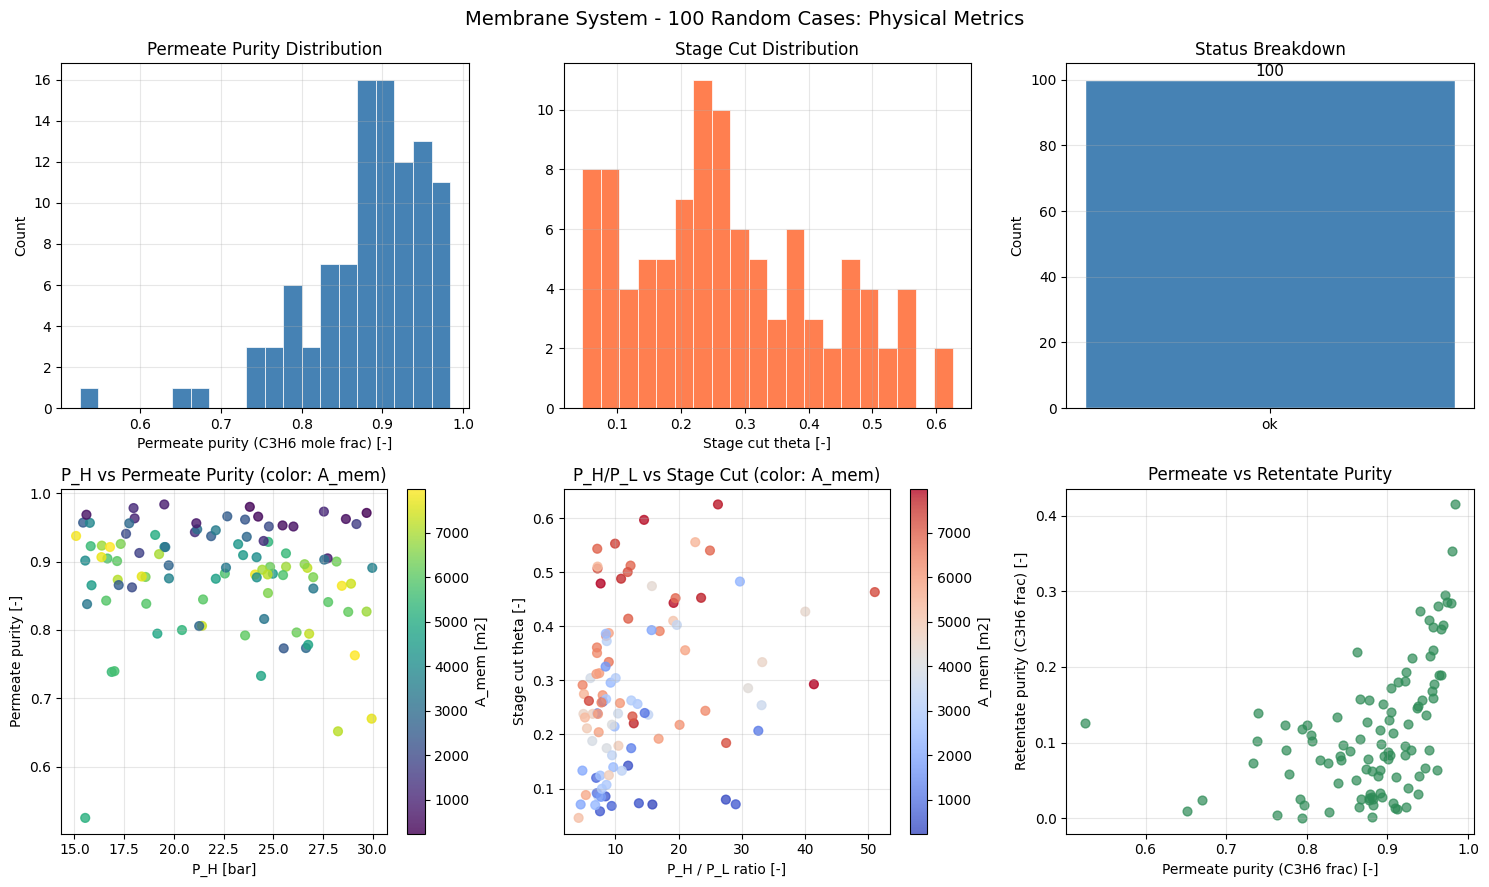

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Membrane System - 100 Random Cases: Physical Metrics', fontsize=14)
STATUS_COLORS = {'ok': 'steelblue', 'penalty': 'orange', 'error': 'crimson'}

axes[0,0].hist(df_ok['perm_purity'].dropna(), bins=20, color='steelblue', edgecolor='white', lw=0.5)
axes[0,0].set_xlabel('Permeate purity (C3H6 mole frac) [-]'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Permeate Purity Distribution'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df_ok['stage_cut'].dropna(), bins=20, color='coral', edgecolor='white', lw=0.5)
axes[0,1].set_xlabel('Stage cut theta [-]')
axes[0,1].set_title('Stage Cut Distribution'); axes[0,1].grid(True, alpha=0.3)

sc = df['status'].value_counts()
bars = axes[0,2].bar(sc.index, sc.values,
                     color=[STATUS_COLORS.get(s, 'gray') for s in sc.index], edgecolor='white')
for bar, val in zip(bars, sc.values):
    axes[0,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   str(val), ha='center', va='bottom', fontsize=11)
axes[0,2].set_title('Status Breakdown'); axes[0,2].set_ylabel('Count')
axes[0,2].grid(True, alpha=0.3, axis='y')

sc0 = axes[1,0].scatter(df_ok['P_H_bar'], df_ok['perm_purity'],
                        c=df_ok['A_mem'], cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc0, ax=axes[1,0], label='A_mem [m2]')
axes[1,0].set_xlabel('P_H [bar]'); axes[1,0].set_ylabel('Permeate purity [-]')
axes[1,0].set_title('P_H vs Permeate Purity (color: A_mem)'); axes[1,0].grid(True, alpha=0.3)

df_ok_r = df_ok.copy()
df_ok_r['PH_PL_ratio'] = df_ok['P_H_bar'] / df_ok['P_L_bar']
sc1 = axes[1,1].scatter(df_ok_r['PH_PL_ratio'], df_ok['stage_cut'],
                        c=df_ok['A_mem'], cmap='coolwarm', s=40, alpha=0.8)
plt.colorbar(sc1, ax=axes[1,1], label='A_mem [m2]')
axes[1,1].set_xlabel('P_H / P_L ratio [-]'); axes[1,1].set_ylabel('Stage cut theta [-]')
axes[1,1].set_title('P_H/P_L vs Stage Cut (color: A_mem)'); axes[1,1].grid(True, alpha=0.3)

axes[1,2].scatter(df_ok['perm_purity'], df_ok['ret_purity'],
                  alpha=0.7, color='seagreen', s=40)
axes[1,2].set_xlabel('Permeate purity (C3H6 frac) [-]'); axes[1,2].set_ylabel('Retentate purity (C3H6 frac) [-]')
axes[1,2].set_title('Permeate vs Retentate Purity'); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

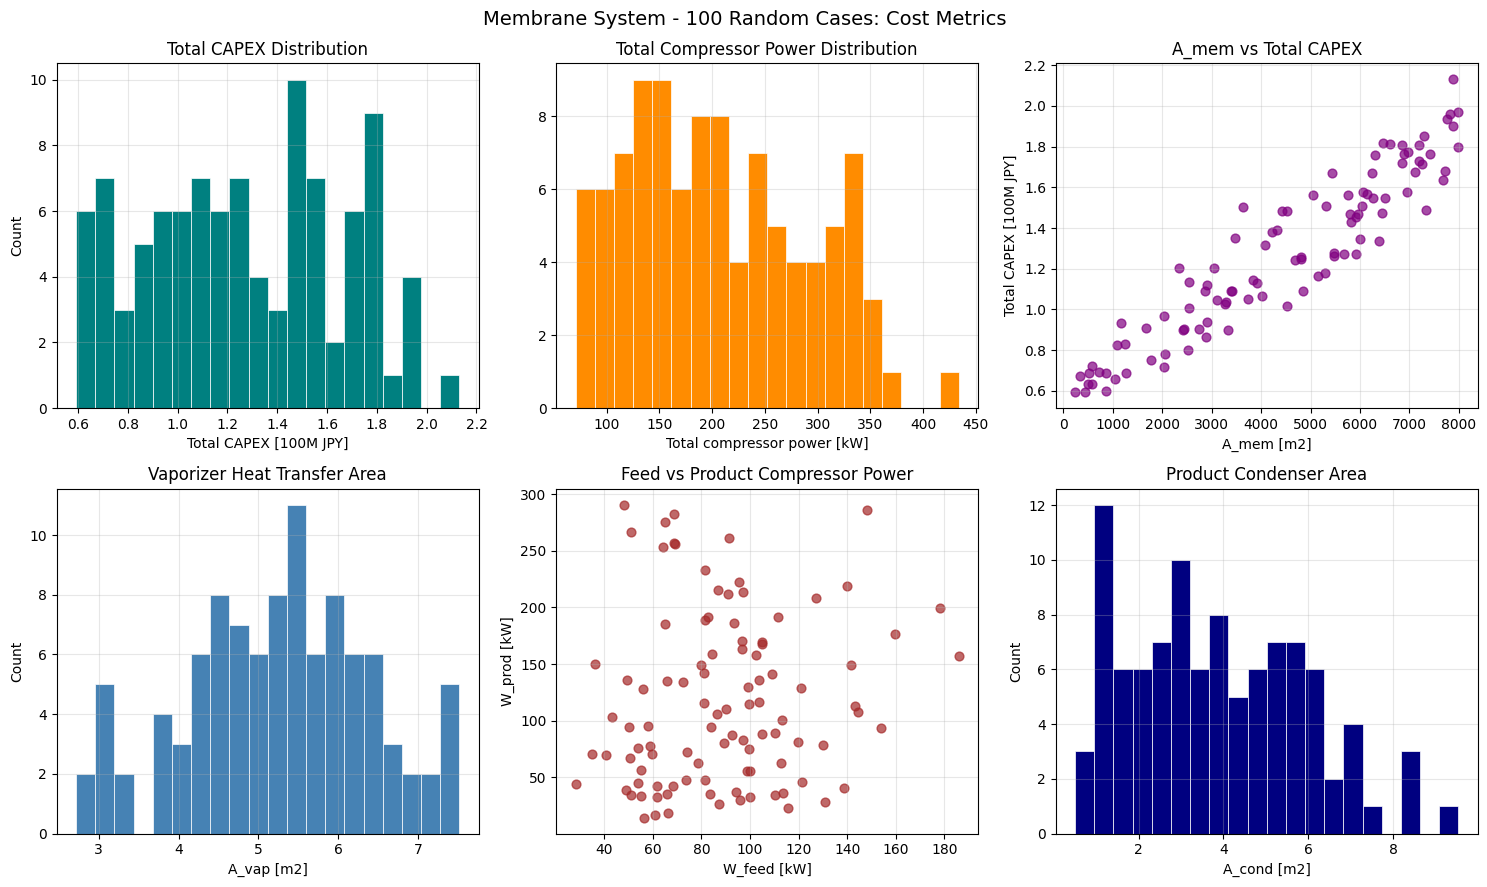

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Membrane System - 100 Random Cases: Cost Metrics', fontsize=14)

axes[0,0].hist(df_ok['CAPEX_total'].dropna(), bins=20, color='teal', edgecolor='white', lw=0.5)
axes[0,0].set_xlabel('Total CAPEX [100M JPY]'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Total CAPEX Distribution'); axes[0,0].grid(True, alpha=0.3)

df_ok_w = df_ok.copy()
df_ok_w['W_total_kW'] = df_ok['W_feed_kW'] + df_ok['W_prod_kW']
axes[0,1].hist(df_ok_w['W_total_kW'].dropna(), bins=20, color='darkorange', edgecolor='white', lw=0.5)
axes[0,1].set_xlabel('Total compressor power [kW]')
axes[0,1].set_title('Total Compressor Power Distribution'); axes[0,1].grid(True, alpha=0.3)

axes[0,2].scatter(df_ok['A_mem'], df_ok['CAPEX_total'], alpha=0.7, color='purple', s=40)
axes[0,2].set_xlabel('A_mem [m2]'); axes[0,2].set_ylabel('Total CAPEX [100M JPY]')
axes[0,2].set_title('A_mem vs Total CAPEX'); axes[0,2].grid(True, alpha=0.3)

axes[1,0].hist(df_ok['A_vap'].dropna(), bins=20, color='steelblue', edgecolor='white', lw=0.5)
axes[1,0].set_xlabel('A_vap [m2]'); axes[1,0].set_ylabel('Count')
axes[1,0].set_title('Vaporizer Heat Transfer Area'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(df_ok['W_feed_kW'], df_ok['W_prod_kW'], alpha=0.7, color='brown', s=40)
axes[1,1].set_xlabel('W_feed [kW]'); axes[1,1].set_ylabel('W_prod [kW]')
axes[1,1].set_title('Feed vs Product Compressor Power'); axes[1,1].grid(True, alpha=0.3)

axes[1,2].hist(df_ok['A_cond'].dropna(), bins=20, color='navy', edgecolor='white', lw=0.5)
axes[1,2].set_xlabel('A_cond [m2]'); axes[1,2].set_ylabel('Count')
axes[1,2].set_title('Product Condenser Area'); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Section 2 - Physical Consistency Checks

In [6]:
checks = []

def chk(label, series_bool, note=''):
    passed = bool(series_bool.all())
    n_fail = int((~series_bool).sum())
    checks.append({'Test': label,
                   'Result': PASS_STR if passed else FAIL_STR,
                   'Failures': 0 if passed else n_fail,
                   'Note': note})
    return passed

chk('0 <= perm_purity <= 1',
    df_ok['perm_purity'].between(0.0, 1.0), 'mole frac in [0,1]')
chk('0 <= ret_purity <= 1',
    df_ok['ret_purity'].between(0.0, 1.0), 'mole frac in [0,1]')
chk('0 <= stage_cut <= 1',
    df_ok['stage_cut'].between(0.0, 1.0), 'stage cut in [0,1]')
chk('perm_purity > ret_purity',
    df_ok['perm_purity'] > df_ok['ret_purity'], 'alpha=90 > 1: permeate enriches C3H6')
chk('perm_purity > z_C3H6_feed',
    df_ok['perm_purity'] > df_ok['z_C3H6_feed'], 'alpha > 1: permeate C3H6 > feed')

bal_C3H6 = (
    (df_ok['F_prod_C3H6'] + df_ok['F_ret_C3H6'] - df_ok['F_C3H6_in']).abs()
    / df_ok['F_C3H6_in'] < 1e-6
)
chk('C3H6 mass balance (rel err < 1e-6)', bal_C3H6, 'permeate + retentate = feed')

bal_C3H8 = (
    (df_ok['F_prod_C3H8'] + df_ok['F_ret_C3H8'] - df_ok['F_C3H8_in']).abs()
    / df_ok['F_C3H8_in'] < 1e-6
)
chk('C3H8 mass balance (rel err < 1e-6)', bal_C3H8, 'permeate + retentate = feed')
chk('W_feed_kW > 0', df_ok['W_feed_kW'] > 0.0, 'P_H > P_in -> compression work > 0')
chk('W_prod_kW > 0', df_ok['W_prod_kW'] > 0.0, 'P_dist > P_L -> compression work > 0')
chk('CAPEX_total > 0', df_ok['CAPEX_total'] > 0.0, 'valid equipment cost > 0')
chk('T_prod_out_C > 40 (cooling water condensable)',
    df_ok['T_prod_out_C'] > 40.0, 'T_bp > T_cold_out enforced in simulate')

df_checks = pd.DataFrame(checks)
print(df_checks.to_string(index=False))
n_phys_fail = (df_checks['Result'] == FAIL_STR).sum()
print()
print(f'==> {len(checks) - n_phys_fail}/{len(checks)} checks PASS')

                                         Test Result  Failures                                   Note
                        0 <= perm_purity <= 1   PASS         0                     mole frac in [0,1]
                         0 <= ret_purity <= 1   PASS         0                     mole frac in [0,1]
                          0 <= stage_cut <= 1   PASS         0                     stage cut in [0,1]
                     perm_purity > ret_purity   PASS         0   alpha=90 > 1: permeate enriches C3H6
                    perm_purity > z_C3H6_feed   PASS         0        alpha > 1: permeate C3H6 > feed
           C3H6 mass balance (rel err < 1e-6)   PASS         0            permeate + retentate = feed
           C3H8 mass balance (rel err < 1e-6)   PASS         0            permeate + retentate = feed
                                W_feed_kW > 0   PASS         0     P_H > P_in -> compression work > 0
                                W_prod_kW > 0   PASS         0   P_dist > P_L -> c

---
## Section 3 - Cost Calculation Verification

**Membrane module:**
```
C_mem [USD] = MEM_UNIT_PRICE x A_mem x (CEPCI_CURRENT / CEPCI_BASE)
CAPEX_mem   = PLANT_INDIRECT_FACTOR x C_mem x USD_TO_JPY / 1e8
```

**Vaporizer (heat exchanger):**
```
Cp0 = 10^(K1_HE + K2_HE x log10(A) + K3_HE x log10(A)^2)
Cbm = Cp0 x (B1_HE + B2_HE x Fp x FM)
CAPEX_vap = PLANT_INDIRECT_FACTOR x Cbm x (CEPCI_CURRENT/CEPCI_BASE) x USD_TO_JPY / 1e8
```

In [7]:
row   = df_ok.iloc[0]
i_idx = int(row['i'])

design0 = MemDesignVars(
    P_H    = float(P_H_arr[i_idx]),
    P_L    = float(P_L_arr[i_idx]),
    A_mem  = float(A_mem_arr[i_idx]),
    P_dist = float(P_dist_arr[i_idx]),
)
feed0 = MemFeedStream(
    F_C3H6 = float(F_C3H6_arr[i_idx]),
    F_C3H8 = float(F_C3H8_arr[i_idx]),
    T_in   = float(T_in_arr[i_idx]),
    P_in   = float(P_in_arr[i_idx]),
)
r0 = simulate_membrane_system(design0, feed0, fixed)

A_mem_val      = float(A_mem_arr[i_idx])
A_vap_val      = r0.equipment.A_vap
capex_mem_sim  = r0.equipment.CAPEX_mem
capex_vap_sim  = r0.equipment.CAPEX_vap

print(f'Case: i={i_idx}')
print(f'  A_mem  = {A_mem_val:.2f} m2')
print(f'  A_vap  = {A_vap_val:.4f} m2')
print(f'  P_H    = {P_H_arr[i_idx]/1e5:.2f} bar')
print(f'  P_dist = {P_dist_arr[i_idx]/1e5:.2f} bar')
print()

cost_usd_mem   = MEM_UNIT_PRICE_USD_PER_M2 * A_mem_val * (CEPCI_CURRENT / CEPCI_BASE)
capex_mem_calc = PLANT_INDIRECT_FACTOR * cost_usd_mem * USD_TO_JPY / 1.0e8

print('--- Membrane module CAPEX ---')
print(f'  MEM_UNIT_PRICE        = {MEM_UNIT_PRICE_USD_PER_M2} USD/m2  (placeholder)')
print(f'  A_mem                 = {A_mem_val:.2f} m2')
print(f'  CEPCI factor          = {CEPCI_CURRENT/CEPCI_BASE:.6f}  ({CEPCI_CURRENT}/{CEPCI_BASE})')
print(f'  C_mem                 = {cost_usd_mem:>12,.1f} USD')
print(f'  PLANT_INDIRECT_FACTOR = {PLANT_INDIRECT_FACTOR}')
print(f'  CAPEX_mem (calc)      = {capex_mem_calc:.8f} 100M JPY')
print(f'  CAPEX_mem (sim)       = {capex_mem_sim:.8f} 100M JPY')
err_mem = abs(capex_mem_calc - capex_mem_sim)
print(f'  abs error             = {err_mem:.2e}  =>  {PASS_STR if err_mem < 1e-9 else FAIL_STR}')
print()

log_A      = math.log10(A_vap_val)
cp0_he     = 10.0 ** (K1_HE + K2_HE * log_A + K3_HE * log_A**2)
cbm_he     = cp0_he * (B1_HE + B2_HE * FP_HE_DEFAULT * FM_HE)
cur_usd_he = cbm_he * (CEPCI_CURRENT / CEPCI_BASE)
capex_vap_calc = PLANT_INDIRECT_FACTOR * cur_usd_he * USD_TO_JPY / 1.0e8

print('--- Vaporizer (heat exchanger) CAPEX ---')
print(f'  log10(A_vap)     = {log_A:.6f}')
print(f'  Cp0              = {cp0_he:>12,.1f} USD  (K1={K1_HE}, K2={K2_HE}, K3={K3_HE})')
print(f'  Fp={FP_HE_DEFAULT}, FM={FM_HE}')
print(f'  FBM              = {B1_HE + B2_HE*FP_HE_DEFAULT*FM_HE:.4f}  (B1={B1_HE}, B2={B2_HE})')
print(f'  Cbm              = {cbm_he:>12,.1f} USD')
print(f'  Current cost     = {cur_usd_he:>12,.1f} USD')
print(f'  CAPEX_vap (calc) = {capex_vap_calc:.8f} 100M JPY')
print(f'  CAPEX_vap (sim)  = {capex_vap_sim:.8f} 100M JPY')
err_vap = abs(capex_vap_calc - capex_vap_sim)
print(f'  abs error        = {err_vap:.2e}  =>  {PASS_STR if err_vap < 1e-9 else FAIL_STR}')

Case: i=0
  A_mem  = 3924.55 m2
  A_vap  = 7.3567 m2
  P_H    = 19.53 bar
  P_dist = 20.41 bar

--- Membrane module CAPEX ---
  MEM_UNIT_PRICE        = 50.0 USD/m2  (placeholder)
  A_mem                 = 3924.55 m2
  CEPCI factor          = 1.370277  (544.0/397.0)
  C_mem                 =    268,885.8 USD
  PLANT_INDIRECT_FACTOR = 1.18
  CAPEX_mem (calc)      = 0.49839158 100M JPY
  CAPEX_mem (sim)       = 0.49839158 100M JPY
  abs error             = 0.00e+00  =>  PASS

--- Vaporizer (heat exchanger) CAPEX ---
  log10(A_vap)     = 0.866680
  Cp0              =     15,304.9 USD  (K1=4.3247, K2=-0.303, K3=0.1634)
  Fp=1.0, FM=1.0
  FBM              = 3.2900  (B1=1.63, B2=1.66)
  Cbm              =     50,353.2 USD
  Current cost     =     68,997.9 USD
  CAPEX_vap (calc) = 0.12789056 100M JPY
  CAPEX_vap (sim)  = 0.12789056 100M JPY
  abs error        = 0.00e+00  =>  PASS


---
## Section 4 - Error Handling Verification

Expected penalty values:
- `CAPEX_total = 1e9` [100M JPY]
- `stage_cut = 0.0`
- `perm_purity = 0.0`
- `ret_purity = 0.0`

In [8]:
_PENALTY_CAPEX = 1e9

valid_design = MemDesignVars(
    P_H    = 20e5,
    P_L    =  1e5,
    A_mem  = 2000.0,
    P_dist = 22e5,
)
valid_feed = MemFeedStream(
    F_C3H6 = 40.0,
    F_C3H8 = 100.0,
    T_in   = 270.0,
    P_in   = 10e5,
)
_fixed = MemFixedParams()

def _run(label, d, f):
    try:
        r = simulate_membrane_system(d, f, _fixed)
        ok = (abs(r.equipment.CAPEX_total - _PENALTY_CAPEX) < 1.0
              and r.stage_cut   == 0.0
              and r.perm_purity == 0.0
              and r.ret_purity  == 0.0)
        return {'Case': label,
                'Result': PASS_STR if ok else FAIL_STR,
                'CAPEX': f'{r.equipment.CAPEX_total:.1e}',
                'stage_cut'  : r.stage_cut,
                'perm_purity': r.perm_purity}
    except Exception as e:
        return {'Case': label, 'Result': f'{FAIL_STR} exception:{e}',
                'CAPEX': '-', 'stage_cut': '-', 'perm_purity': '-'}

def _d(**kw):
    d = copy.deepcopy(valid_design)
    for k, v in kw.items(): setattr(d, k, v)
    return d

def _f(**kw):
    f = copy.deepcopy(valid_feed)
    for k, v in kw.items(): setattr(f, k, v)
    return f

rows = [
    _run('A_mem = 0',            _d(A_mem=0.0), valid_feed),
    _run('P_H = 0',              _d(P_H=0.0),   valid_feed),
    _run('P_L = 0',              _d(P_L=0.0),   valid_feed),
    _run('P_H = P_L (no driving force)', _d(P_H=1e5), _f(P_in=0.5e5)),
    _run('P_H <= P_in (compressor reversal)', _d(P_H=10e5), valid_feed),
    _run('P_in = 0',             valid_design,  _f(P_in=0.0)),
    _run('T_in = 0',             valid_design,  _f(T_in=0.0)),
    _run('F_C3H6 < 0',           valid_design,
         MemFeedStream(F_C3H6=-1.0, F_C3H8=100.0, T_in=270.0, P_in=10e5)),
    _run('F_in all zero',        valid_design,
         MemFeedStream(F_C3H6=0.0,  F_C3H8=0.0,   T_in=270.0, P_in=10e5)),
]

df_eh = pd.DataFrame(rows)
print(df_eh.to_string(index=False))
n_eh_pass = (df_eh['Result'] == PASS_STR).sum()
print()
print(f'==> {n_eh_pass}/{len(rows)} cases PASS')

                             Case Result   CAPEX  stage_cut  perm_purity
                        A_mem = 0   PASS 1.0e+09        0.0          0.0
                          P_H = 0   PASS 1.0e+09        0.0          0.0
                          P_L = 0   PASS 1.0e+09        0.0          0.0
     P_H = P_L (no driving force)   PASS 1.0e+09        0.0          0.0
P_H <= P_in (compressor reversal)   PASS 1.0e+09        0.0          0.0
                         P_in = 0   PASS 1.0e+09        0.0          0.0
                         T_in = 0   PASS 1.0e+09        0.0          0.0
                       F_C3H6 < 0   PASS 1.0e+09        0.0          0.0
                    F_in all zero   PASS 1.0e+09        0.0          0.0

==> 9/9 cases PASS


In [9]:
print('=' * 60)
print('  Membrane System Comprehensive Test - Summary')
print('=' * 60)

s1_err   = int((df['status'] == 'error').sum())
s1_ok    = len(df_ok)
s2_fail  = int((df_checks['Result'] == FAIL_STR).sum())
s3_ok_m  = err_mem < 1e-9
s3_ok_v  = err_vap < 1e-9
s4_pass  = int((df_eh['Result'] == PASS_STR).sum())

print(f'[Sec 1] Random 100 cases        : ok={s1_ok}/100  error={s1_err}/100')
print(f'[Sec 2] Physical consistency    : {len(checks)-s2_fail}/{len(checks)} checks PASS')
print(f'[Sec 3] Cost verification       : '
      f'mem err={err_mem:.2e} => {PASS_STR if s3_ok_m else FAIL_STR},  '
      f'vap err={err_vap:.2e} => {PASS_STR if s3_ok_v else FAIL_STR}')
print(f'[Sec 4] Error handling          : {s4_pass}/{len(rows)} cases PASS')

all_ok = (s1_err == 0 and s2_fail == 0 and s3_ok_m and s3_ok_v and s4_pass == len(rows))
print()
print('  => ALL PASS' if all_ok else '  => SOME FAILURES - check above')
print('=' * 60)

  Membrane System Comprehensive Test - Summary
[Sec 1] Random 100 cases        : ok=100/100  error=0/100
[Sec 2] Physical consistency    : 11/11 checks PASS
[Sec 3] Cost verification       : mem err=0.00e+00 => PASS,  vap err=0.00e+00 => PASS
[Sec 4] Error handling          : 9/9 cases PASS

  => ALL PASS
